# **Import Libraries**

In [74]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from xgboost import XGBClassifier
from sklearn.svm import SVC

from sklearn.metrics import (accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay)

# **Load the Dataset**

In [75]:
df = pd.read_csv(r"C:\Users\LAPTOP\OneDrive\Attachments\Desktop\Predictive_Maintenance_1.1.csv")

In [76]:
df.head()

,date,device,Product ID,Type,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,1/1/2015,Z1F0LSHN,L48197,L,23.15,34.05,1637.0,31.6,27,1
1,1/4/2015,Z1F0MSSJ,L51715,L,29.25,37.05,1503.0,36.2,166,0
2,1/6/2015,Z1F0W23J,L53989,L,27.75,37.65,1490.0,38.1,125,0
3,1/1/2015,S1F049RX,L47205,L,25.85,36.35,1861.0,23.3,73,0
4,1/9/2015,W1F1CKKW,M23857,M,23.95,34.75,1609.0,38.9,166,0


In [77]:
df.tail()

,date,device,Product ID,Type,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
15995,1/4/2015,S1F11L11,M18791,M,29.55,38.55,NaN,25.1,177,1
15996,1/2/2015,S1F0R12Y,H30782,H,25.65,37.15,1708.0,27.1,78,0
15997,1/6/2015,S1F0LLKM,M20772,M,27.55,37.15,1659.0,29.8,6,0
15998,1/2/2015,W1F0RN8N,H39773,H,27.98,36.65,1306.0,66.3,153,1
15999,1/1/2015,S1F0M2PQ,L47319,L,25.65,35.45,1268.0,55.8,155,0


In [78]:
df.shape

(16000, 10)

# **EDA**

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   date                    16000 non-null  str    
 1   device                  16000 non-null  str    
 2   Product ID              16000 non-null  str    
 3   Type                    15994 non-null  str    
 4   Air temperature         15993 non-null  float64
 5   Process temperature     15994 non-null  float64
 6   Rotational speed [rpm]  15991 non-null  float64
 7   Torque [Nm]             16000 non-null  float64
 8   Tool wear [min]         16000 non-null  int64  
 9   Machine failure         16000 non-null  int64  
dtypes: float64(4), int64(2), str(4)
memory usage: 1.2 MB


In [80]:
df.duplicated().sum()

np.int64(0)

In [123]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Air temperature,16000.0,26.985500,2.102971,22.15,25.25,27.05,28.68,31.35
Process temperature,16000.0,36.887516,1.563183,32.55,35.65,36.95,38.02,40.65
Rotational speed [rpm],16000.0,1589.999125,259.892857,1168.00,1403.00,1518.00,1710.00,2886.00
Torque [Nm],16000.0,38.868194,12.986979,3.80,28.70,38.95,48.80,76.60
Tool wear [min],16000.0,110.330125,68.171603,0.00,46.00,111.00,173.00,253.00
Machine failure,16000.0,0.460000,0.498413,0.00,0.00,0.00,1.00,1.00
Type_L,16000.0,0.612000,0.487310,0.00,0.00,1.00,1.00,1.00
Type_M,16000.0,0.290812,0.454151,0.00,0.00,0.00,1.00,1.00


In [83]:
df = df.drop(['date','device','Product ID'], axis=1)

# **Check Nulls**

In [84]:
df.isnull().sum()

Type                      6
Air temperature           7
Process temperature       6
Rotational speed [rpm]    9
Torque [Nm]               0
Tool wear [min]           0
Machine failure           0
dtype: int64

# **Visualization**

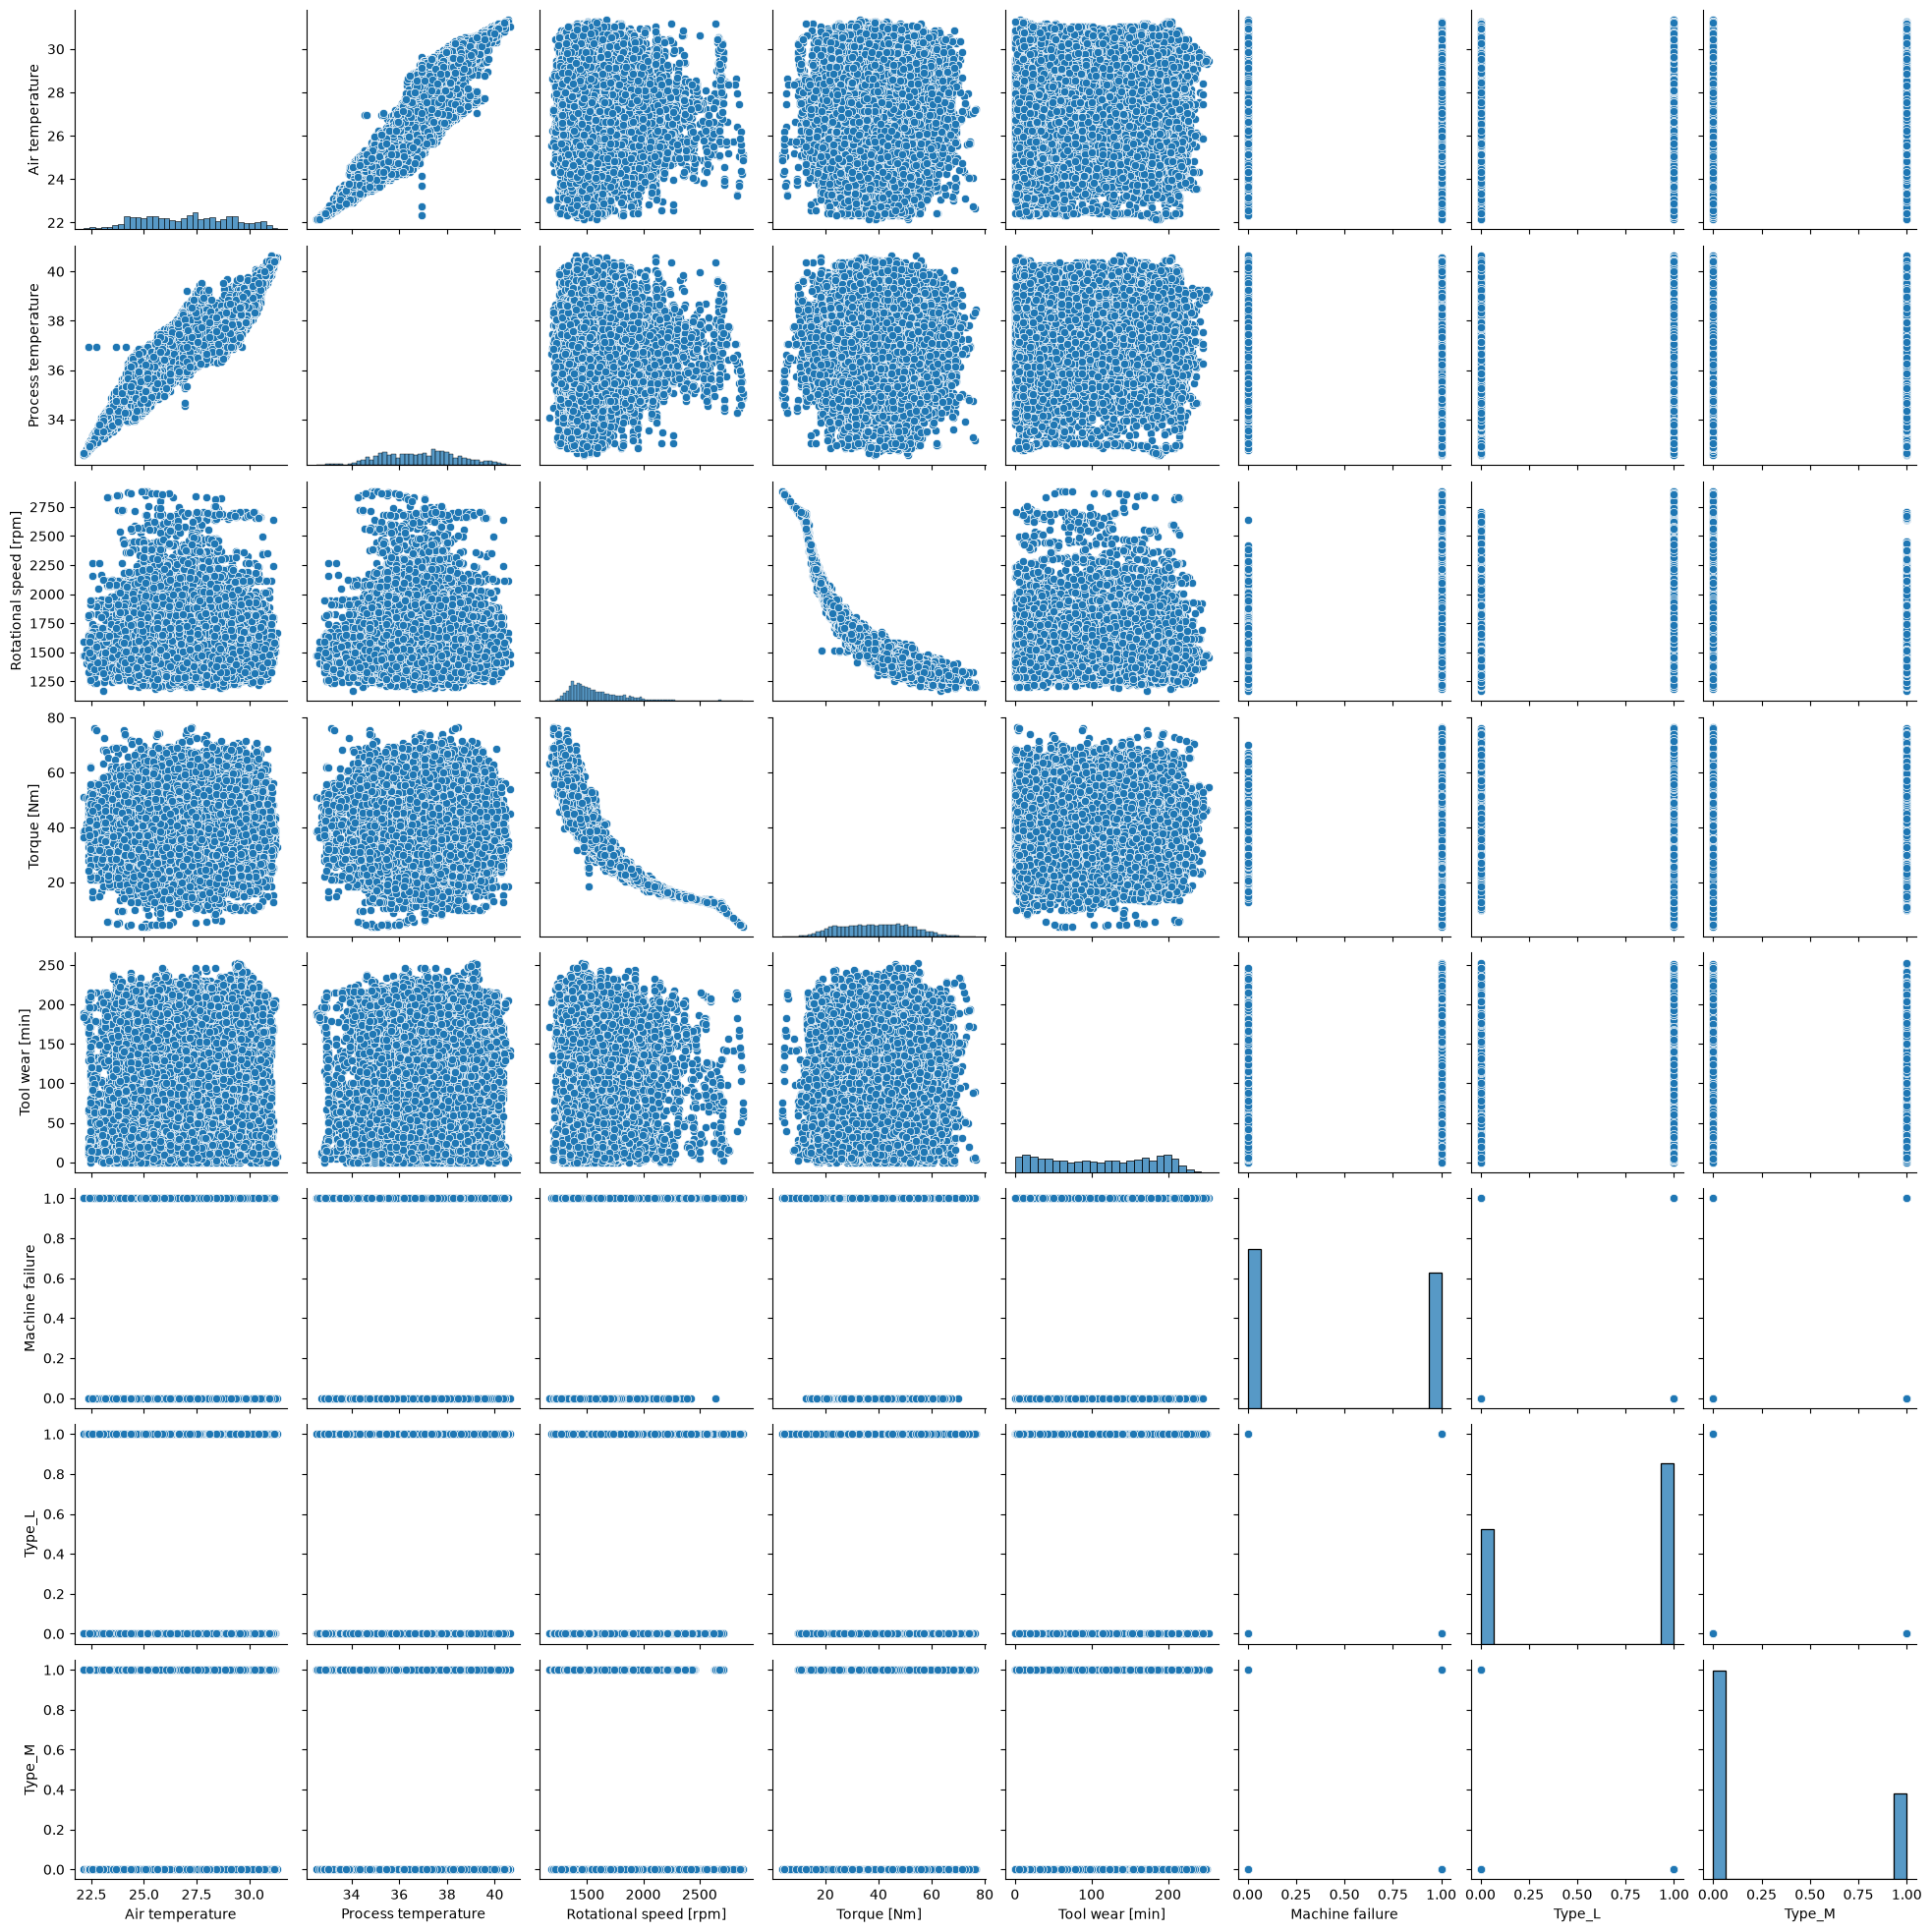

In [120]:
sns.pairplot(df)
plt.show()

In [85]:
df["Machine failure"].value_counts()


Machine failure
0    8640
1    7360
Name: count, dtype: int64

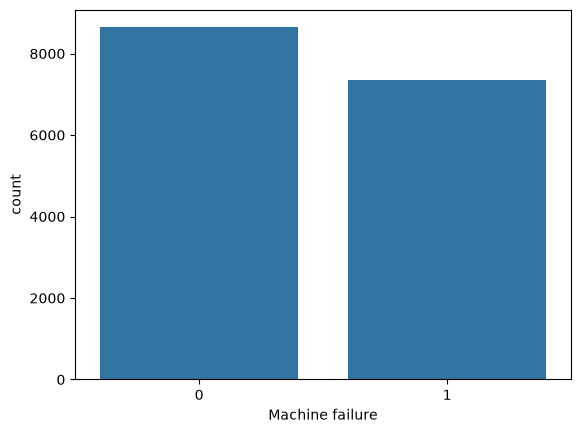

In [86]:
sns.countplot(x="Machine failure", data=df)
plt.show()

In [87]:
df["Type"].value_counts()

Type
L    9786
M    4653
H    1555
Name: count, dtype: int64

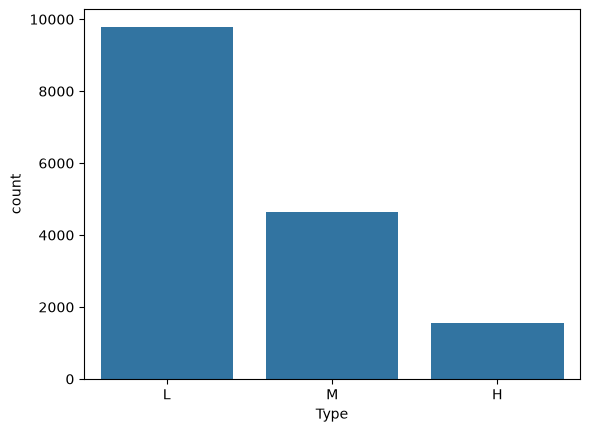

In [88]:
sns.countplot(x="Type", data=df)
plt.show()

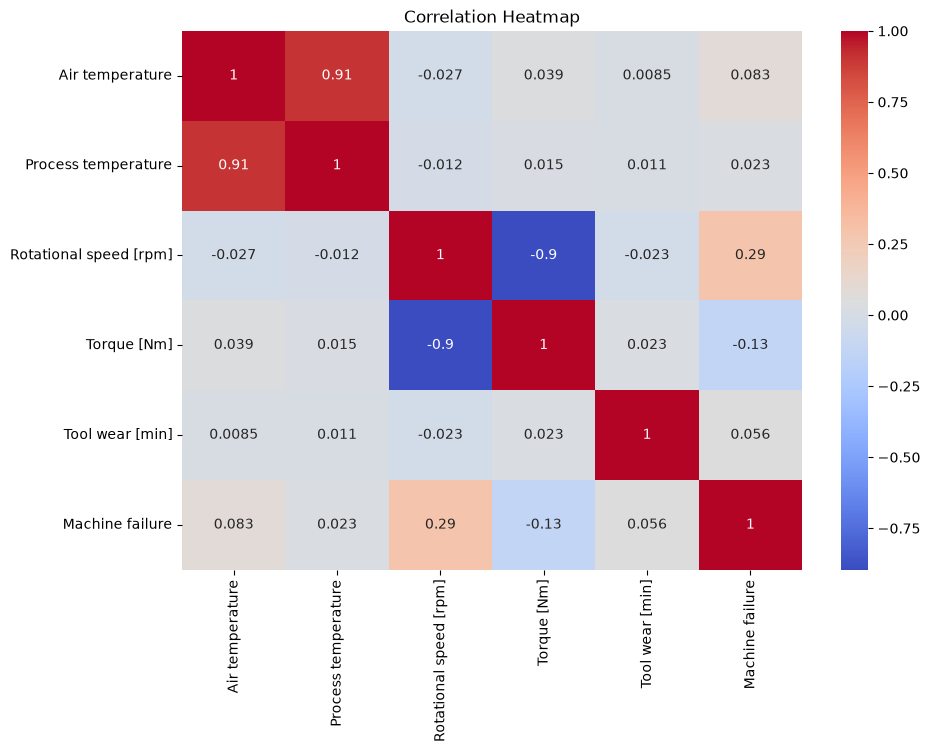

In [89]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# **PreProcessing**

In [90]:
numeric_cols = [
    "Air temperature",
    "Process temperature",
    "Rotational speed [rpm]"
]

imputer = SimpleImputer(strategy="median")

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [91]:
df["Type"] = df["Type"].fillna(df["Type"].mode()[0])

In [92]:
df = pd.get_dummies(
    df,
    columns=["Type"],
    drop_first=True,
    dtype=int
)

In [93]:
df.head()

,Air temperature,Process temperature,Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,Type_L,Type_M
0,23.15,34.05,1637.0,31.6,27,1,1,0
1,29.25,37.05,1503.0,36.2,166,0,1,0
2,27.75,37.65,1490.0,38.1,125,0,1,0
3,25.85,36.35,1861.0,23.3,73,0,1,0
4,23.95,34.75,1609.0,38.9,166,0,0,1


In [94]:
df.isnull().sum()

Air temperature           0
Process temperature       0
Rotational speed [rpm]    0
Torque [Nm]               0
Tool wear [min]           0
Machine failure           0
Type_L                    0
Type_M                    0
dtype: int64

# **Split Into** X & y

In [95]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]


In [96]:
feature_columns = X.columns.tolist()
print(feature_columns)

['Air temperature', 'Process temperature', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_L', 'Type_M']


# **Train Test Split**

In [97]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.1, random_state=42, stratify=y)

# **Scaling**

In [98]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Models**

**LogisticRegression**

In [99]:
model = LogisticRegression()

model.fit( X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [100]:
y_pred = model.predict(X_test)

In [101]:
accuracy = accuracy_score( y_test, y_pred )

print("Accuracy:", accuracy)
print("\nClassification Report:")
print( classification_report( y_test, y_pred ))

Accuracy: 0.71

Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.80      0.75       864
           1       0.72      0.60      0.66       736

    accuracy                           0.71      1600
   macro avg       0.71      0.70      0.70      1600
weighted avg       0.71      0.71      0.71      1600



 **RandomForest**

In [102]:
rf = RandomForestClassifier( n_estimators=300 )
rf.fit( X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [103]:
y_pred_rf = rf.predict(X_test)

print( "Accuracy:", accuracy_score( y_test, y_pred_rf))
print("\nClassification Report:")
print( classification_report( y_test, y_pred_rf ))

Accuracy: 0.919375

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.93       864
           1       0.91      0.92      0.91       736

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



**DecisionTree**

In [104]:
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit( X_train, y_train )

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

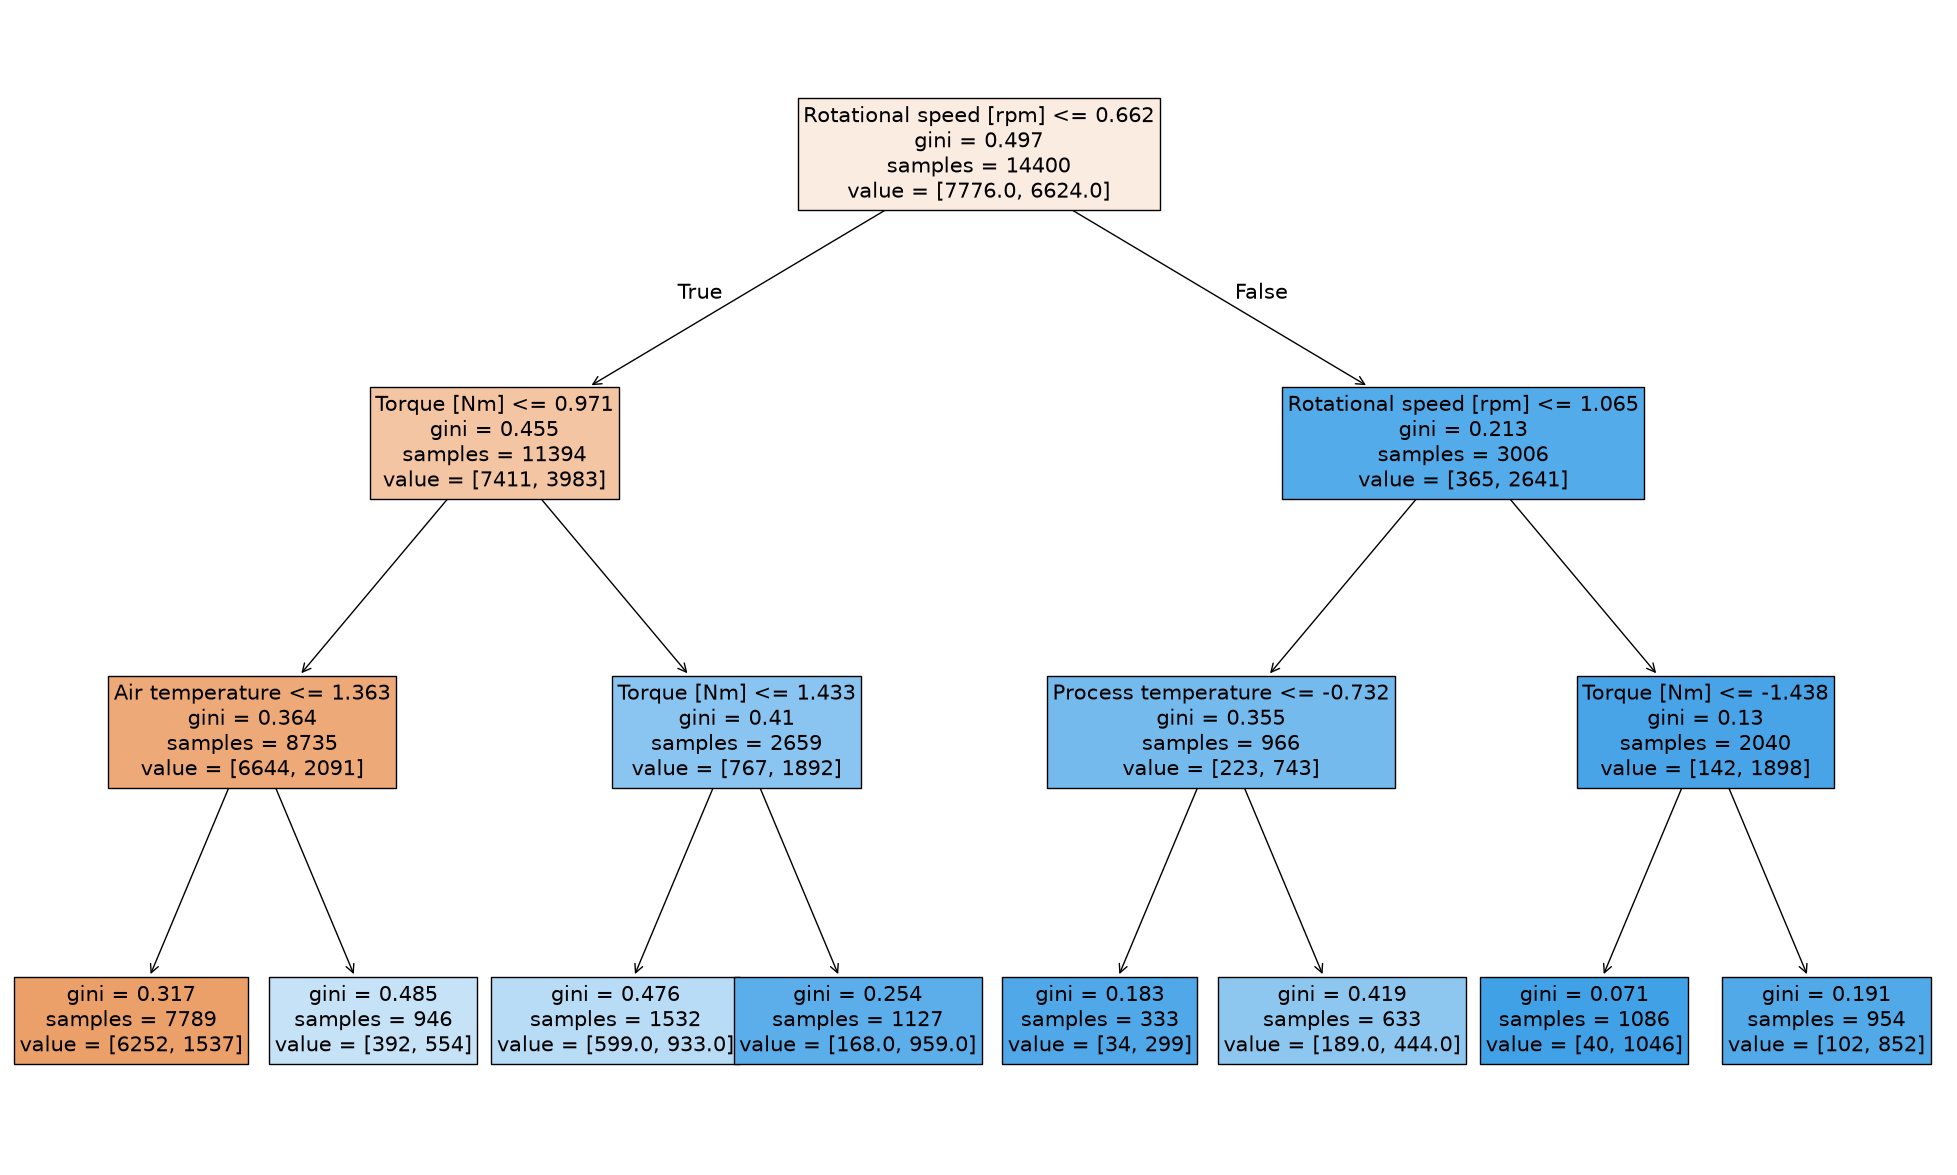

In [105]:
plt.figure(figsize=(25,15))
plot_tree(dt, filled=True, feature_names=feature_columns, fontsize=15)
plt.show()

In [106]:
y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print( "Accuracy:", accuracy_score( y_test, y_pred_dt ))
print( classification_report( y_test, y_pred_dt ))

Decision Tree
Accuracy: 0.77
              precision    recall  f1-score   support

           0       0.79      0.79      0.79       864
           1       0.75      0.75      0.75       736

    accuracy                           0.77      1600
   macro avg       0.77      0.77      0.77      1600
weighted avg       0.77      0.77      0.77      1600



**SVM**


In [107]:
svm = SVC()
svm.fit( X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [108]:
y_pred_svm = svm.predict(X_test)

print("SVM")
print( "Accuracy:", accuracy_score( y_test, y_pred_svm ))
print(classification_report( y_test, y_pred_svm ))

SVM
Accuracy: 0.878125
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       864
           1       0.86      0.88      0.87       736

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



**KNN**


In [109]:
knn = KNeighborsClassifier( n_neighbors=3 )
knn.fit( X_train, y_train )

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [110]:
y_pred_knn = knn.predict(X_test)

print("KNN")
print( "Accuracy:", accuracy_score( y_test, y_pred_knn ))
print( classification_report( y_test, y_pred_knn ))

KNN
Accuracy: 0.895625
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       864
           1       0.86      0.92      0.89       736

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600



**XGBoost**

In [111]:
xgb = XGBClassifier()
xgb.fit( X_train, y_train )

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [112]:
y_pred_xgb = xgb.predict(X_test)

print( "XGBoost Accuracy:", accuracy_score( y_test, y_pred_xgb ))
print( classification_report( y_test, y_pred_xgb ))

XGBoost Accuracy: 0.94875
              precision    recall  f1-score   support

           0       0.96      0.95      0.95       864
           1       0.94      0.95      0.94       736

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



**AdaBoost**

In [113]:
ada = AdaBoostClassifier()
ada.fit( X_train, y_train )

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",50
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels.","ndarray[int64](2,)","[0,1]"
estimator_ estimator_: estimatorThe base estimator from which the ensemble is grown... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,DecisionTreeClassifier,DecisionTreeC...r(max_depth=1)
estimator_errors_ estimator_errors_: ndarray of floatsClassification error for each estimator in the boostedensemble.,"ndarray[float64](50,)","[0.3 ,0.41,0.36,...,0.49,0.45,0.44]"
estimator_weights_ estimator_weights_: ndarray of floatsWeights for each estimator in the boosted ensemble.,"ndarray[float64](50,)","[0.84,0.36,0.57,...,0.06,0.2 ,0.22]"
estimators_ estimators_: list of classifiersThe collection of fitted sub-estimators.,list,"[DecisionTreeC...te=1717968839), DecisionTreeC...tate=60728885), DecisionTreeC...ate=651812794), DecisionTreeC...ate=210466108), ...]"
"feature_importances_ feature_importances_: ndarray of shape (n_features,)The impurity-based feature importances if supported by the``estimator`` (when based on decision trees).Warning: impurity-based feature importances can be misleading forhigh cardinality features (many unique values). See:func:`sklearn.inspection.permutation_importance` as an alternative.","ndarray[float64](7,)","[0.07,0.19,0.28,...,0.18,0. ,0. ]"


In [114]:
y_pred_ada = ada.predict(X_test)

print( "AdaBoost Accuracy:", accuracy_score( y_test, y_pred_ada ))
print( classification_report( y_test, y_pred_ada ))

AdaBoost Accuracy: 0.83125
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       864
           1       0.84      0.78      0.81       736

    accuracy                           0.83      1600
   macro avg       0.83      0.83      0.83      1600
weighted avg       0.83      0.83      0.83      1600



## Confusion Matrix

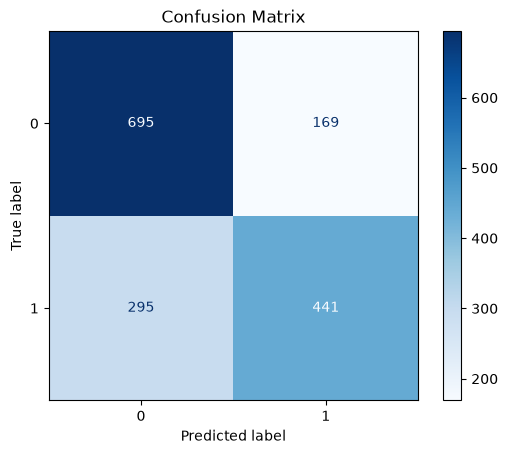

In [115]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0 , 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

# Feature Importance

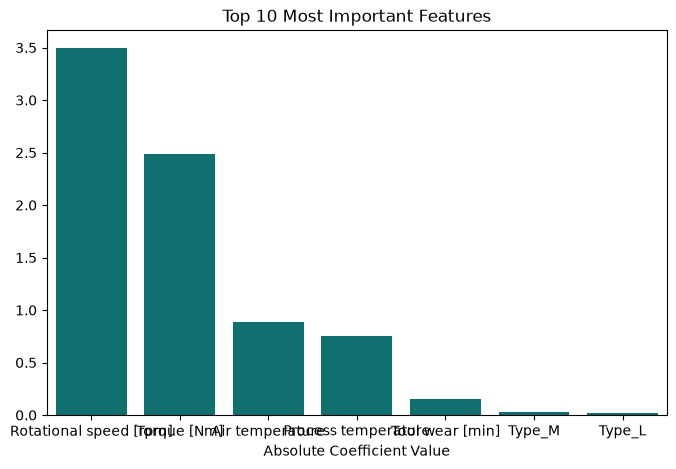

In [118]:
importances = pd.Series(abs(model.coef_[0]), index=X.columns)
top_features = importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
sns.barplot(y=top_features.values, x=top_features.index, color="teal")
plt.title("Top 10 Most Important Features")
plt.xlabel("Absolute Coefficient Value")
plt.show()

# **UI**

In [119]:
import gradio as gr


def predict_machine(
    air_temperature,
    process_temperature,
    rotational_speed,
    torque,
    tool_wear,
    machine_type
):

    input_data = pd.DataFrame({

        "Air temperature": [
            air_temperature
        ],

        "Process temperature": [
            process_temperature
        ],

        "Rotational speed [rpm]": [
            rotational_speed
        ],

        "Torque [Nm]": [
            torque
        ],

        "Tool wear [min]": [
            tool_wear
        ],

        "Type_L": [
            1 if machine_type == "L" else 0
        ],

        "Type_M": [
            1 if machine_type == "M" else 0
        ]
    })


    # Same preprocessing used during training

    input_scaled = scaler.transform(
        input_data
    )


    # XGBoost prediction

    prediction = xgb.predict(
        input_scaled
    )[0]


    # Failure probability

    probability = xgb.predict_proba(
        input_scaled
    )[0][1]


    if prediction == 1:

        result = "🔴 MACHINE FAILURE RISK"

        message = (
            "⚠️ Maintenance is recommended."
        )

    else:

        result = "🟢 MACHINE OK"

        message = (
            "✅ The machine is operating normally."
        )


    return (

        f"{result}\n\n"

        f"Failure Probability : "
        f"{probability * 100:.2f}%\n\n"

        f"{message}"
    )


# =========================================================
# Custom CSS
# =========================================================

custom_css = """

.gradio-container {
    max-width: 1000px !important;
    margin: auto !important;
}

.title {
    text-align: center;
}

.subtitle {
    text-align: center;
    color: #6b7280;
}

.result-box textarea {
    text-align: center;
    font-size: 20px !important;
    font-weight: bold;
}

"""


# =========================================================
# Gradio Interface
# =========================================================

with gr.Blocks(
    theme=gr.themes.Soft(),
    css=custom_css
) as interface:


    # -----------------------------------------------------
    # Header
    # -----------------------------------------------------

    gr.Markdown(
        """
        # ⚙️ Machine Failure Prediction

        ### Predictive Maintenance System
        """,

        elem_classes="title"
    )


    gr.Markdown(
        """
        Enter the machine parameters to predict
        whether the machine is likely to fail.
        """,

        elem_classes="subtitle"
    )


    # -----------------------------------------------------
    # Temperature
    # -----------------------------------------------------

    gr.Markdown(
        "## 🌡️ Temperature"
    )


    with gr.Row():

        air_temperature = gr.Number(
            label="Air Temperature (°C)",
            value=26.95
        )


        process_temperature = gr.Number(
            label="Process Temperature (°C)",
            value=36.95
        )


    # -----------------------------------------------------
    # Machine Performance
    # -----------------------------------------------------

    gr.Markdown(
        "## ⚙️ Machine Performance"
    )


    with gr.Row():

        rotational_speed = gr.Number(
            label="Rotational Speed (RPM)",
            value=1503
        )


        torque = gr.Number(
            label="Torque (Nm)",
            value=40
        )


    # -----------------------------------------------------
    # Tool Wear + Machine Type
    # -----------------------------------------------------

    with gr.Row():

        tool_wear = gr.Slider(
            minimum=0,
            maximum=253,
            step=1,
            value=108,
            label="Tool Wear (min)"
        )


        machine_type = gr.Dropdown(
            choices=["L", "M", "H"],
            value="M",
            label="Machine Type"
        )


    # -----------------------------------------------------
    # Prediction Button
    # -----------------------------------------------------

    predict_button = gr.Button(
        "🔍 Predict Machine Status",
        variant="primary",
        size="lg"
    )


    # -----------------------------------------------------
    # Result
    # -----------------------------------------------------

    gr.Markdown(
        "## 📊 Prediction Result"
    )


    result = gr.Textbox(
        label="Machine Status",
        lines=5,
        interactive=False,
        elem_classes="result-box"
    )


    # -----------------------------------------------------
    # Button Action
    # -----------------------------------------------------

    predict_button.click(

        fn=predict_machine,

        inputs=[
            air_temperature,
            process_temperature,
            rotational_speed,
            torque,
            tool_wear,
            machine_type
        ],

        outputs=result
    )


# =========================================================
# Launch
# =========================================================

interface.launch()

C:\Users\LAPTOP\AppData\Local\Temp\ipykernel_20280\426460101.py:127: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


* Running on local URL:  http://127.0.0.1:7863
* To create a public link, set `share=True` in `launch()`.
